# Machine Learning Models for Capacity Factor Prediction

This notebook trains and evaluates multiple machine learning models for predicting power plant capacity factors.

## Objectives
- Train RandomForest, XGBoost, TabNet, and KAN models
- Compare model performance using MAE, RMSE, and R²
- Perform SHAP explainability analysis
- Analyze prediction residuals

In [9]:
import sys
from pathlib import Path
# Add parent directory to path
parent_dir = Path().resolve().parent
sys.path.insert(0, str(parent_dir))
sys.path.append(str(Path.cwd().parent / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from src.preprocessing import Preprocessor
from src.feature_engineering import FeatureEngineer
from src.models import ModelPipeline

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)
torch.manual_seed(42)

%matplotlib inline

## 1. Load and Prepare Data

In [10]:
preprocessor = Preprocessor()
data_path = Path.cwd().parent / 'data' / 'raw' / 'global_power_plant_database.csv'

df = preprocessor.load_data(data_path)
df = preprocessor.clean_data(df)
df = preprocessor.filter_valid_generation(df)

engineer = FeatureEngineer()
df = engineer.engineer_all_features(df)

print(f"Prepared dataset: {len(df):,} plants")
print(f"Features available: {df.shape[1]}")

2026-03-10 11:36:55,092 - INFO - Loading data from e:\Geospatial Machine Learning for Global Power Plant Efficiency and Infrastructure Inequality\data\raw\global_power_plant_database.csv
2026-03-10 11:36:55,381 - INFO - Dataset loaded: 34936 rows, 36 columns
2026-03-10 11:36:55,384 - INFO - Starting data cleaning. Initial rows: 34936
2026-03-10 11:36:55,381 - INFO - Dataset loaded: 34936 rows, 36 columns
2026-03-10 11:36:55,384 - INFO - Starting data cleaning. Initial rows: 34936
2026-03-10 11:36:55,434 - INFO - Duplicates removed: 0 rows
2026-03-10 11:36:55,437 - INFO - Rows after removing missing critical columns: 34936
2026-03-10 11:36:55,439 - INFO - Data cleaning completed. Final rows: 34936
2026-03-10 11:36:55,440 - INFO - Total rows removed: 0
2026-03-10 11:36:55,441 - INFO - Filtering valid generation data. Initial rows: 34936
2026-03-10 11:36:55,434 - INFO - Duplicates removed: 0 rows
2026-03-10 11:36:55,437 - INFO - Rows after removing missing critical columns: 34936
2026-03-

Prepared dataset: 33,045 plants
Features available: 44


## 2. Feature Preparation and Data Split

In [11]:
pipeline = ModelPipeline()

X_train, X_val, X_test, y_train, y_val, y_test = pipeline.create_stratified_split(df)

print(f"\nFeature matrix shape: {X_train.shape[1]} features")
print(f"Training samples: {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Test samples: {len(X_test):,}")

2026-03-10 11:36:55,902 - INFO - Creating stratified train/val/test split
2026-03-10 11:36:55,904 - INFO - Preparing features for modeling
2026-03-10 11:36:55,904 - INFO - Preparing features for modeling
2026-03-10 11:36:55,929 - INFO - Features prepared: 23 features, 33045 samples
2026-03-10 11:36:55,929 - INFO - Features prepared: 23 features, 33045 samples
2026-03-10 11:36:55,956 - INFO - Using stratified split by continent
2026-03-10 11:36:55,956 - INFO - Using stratified split by continent
2026-03-10 11:36:56,028 - INFO - Train size: 23130 (70.0%)
2026-03-10 11:36:56,030 - INFO - Val size: 4958 (15.0%)
2026-03-10 11:36:56,031 - INFO - Test size: 4957 (15.0%)
2026-03-10 11:36:56,028 - INFO - Train size: 23130 (70.0%)
2026-03-10 11:36:56,030 - INFO - Val size: 4958 (15.0%)
2026-03-10 11:36:56,031 - INFO - Test size: 4957 (15.0%)



Feature matrix shape: 23 features
Training samples: 23,130
Validation samples: 4,958
Test samples: 4,957


In [12]:
print("\nTop 20 Features:")
for i, feature in enumerate(pipeline.feature_names[:20], 1):
    print(f"{i:2d}. {feature}")


Top 20 Features:
 1. capacity_mw
 2. latitude
 3. longitude
 4. plant_age
 5. log_capacity_mw
 6. regional_renewable_share
 7. primary_fuel_Coal
 8. primary_fuel_Gas
 9. primary_fuel_Geothermal
10. primary_fuel_Hydro
11. primary_fuel_Nuclear
12. primary_fuel_Oil
13. primary_fuel_Other
14. primary_fuel_Solar
15. primary_fuel_Waste
16. primary_fuel_Wind
17. continent_Africa
18. continent_Asia
19. continent_Europe
20. continent_North America


## 3. Train Models

In [13]:
print("Training Random Forest...")
rf_model = pipeline.train_random_forest(X_train, y_train)
print("✓ Random Forest training complete")

2026-03-10 11:36:56,059 - INFO - Training Random Forest Regressor


Training Random Forest...
Random Forest Training Progress: 100% (100/100 trees)

2026-03-10 11:36:58,591 - INFO - Random Forest training completed



✓ Random Forest training complete


In [14]:
print("Training XGBoost...")
xgb_model = pipeline.train_xgboost(X_train, y_train, X_val, y_val)
print("✓ XGBoost training complete")

2026-03-10 11:36:58,612 - INFO - Training XGBoost Regressor


Training XGBoost...
XGBoost Training Progress: 100% (Tree 100/100)



2026-03-10 11:36:59,405 - INFO - XGBoost training completed


✓ XGBoost training complete


In [17]:
print("Training TabNet...")
tabnet_model = pipeline.train_tabnet(X_train, y_train, X_val, y_val)
print("✓ TabNet training complete")

2026-03-10 11:42:27,152 - INFO - Training TabNet Regressor


Training TabNet...
TabNet Training Progress: 94% (Epoch 47/50)
Early stopping occurred at epoch 46 with best_epoch = 36 and best_val_0_mse = 0.00496

Early stopping occurred at epoch 46 with best_epoch = 36 and best_val_0_mse = 0.00496


c:\Python312\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
2026-03-10 11:48:21,956 - INFO - TabNet training completed
2026-03-10 11:48:21,956 - INFO - TabNet training completed



✓ TabNet training complete


In [19]:
print("Training KAN (Kolmogorov-Arnold Network)...")
kan_model = pipeline.train_kan(X_train, y_train, X_val, y_val)
print("✓ KAN training complete")

2026-03-10 11:48:47,558 - INFO - Training KAN (Kolmogorov-Arnold Network)
2026-03-10 11:48:47,598 - INFO - Set PyTorch to single-threaded mode to avoid MKL conflicts
2026-03-10 11:48:47,600 - INFO - Trying KAN training strategy: Adam with moderate sample and good grid
2026-03-10 11:48:47,598 - INFO - Set PyTorch to single-threaded mode to avoid MKL conflicts
2026-03-10 11:48:47,600 - INFO - Trying KAN training strategy: Adam with moderate sample and good grid


Training KAN (Kolmogorov-Arnold Network)...
KAN Training (Adam with moderate sample and good grid): 

train loss: 1.12e-01 | test loss: 1.53e-01 | reg: 1.14e+02 : 100%|█| 300/300 [06:11<00:00,  1.24s/it
2026-03-10 11:54:59,669 - INFO - KAN training completed with strategy 'Adam with moderate sample and good grid' (trained on 5000 samples)
train loss: 1.12e-01 | test loss: 1.53e-01 | reg: 1.14e+02 : 100%|█| 300/300 [06:11<00:00,  1.24s/it
2026-03-10 11:54:59,669 - INFO - KAN training completed with strategy 'Adam with moderate sample and good grid' (trained on 5000 samples)


 [OK] Completed
✓ KAN training complete


## 4. Model Evaluation

In [20]:
results = []

for model_name, model in pipeline.models.items():
    print(f"\nEvaluating {model_name}...")
    metrics = pipeline.evaluate_model(model, X_test, y_test, model_name)
    results.append({
        'Model': model_name,
        'MAE': metrics['MAE'],
        'RMSE': metrics['RMSE'],
        'R²': metrics['R2']
    })

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print("\n" + "="*60)
print("MODEL COMPARISON RESULTS")
print("="*60)
print(results_df.to_string(index=False))
print("="*60)

2026-03-10 11:55:07,431 - INFO - Evaluating RandomForest
2026-03-10 11:55:07,519 - INFO - RandomForest - MAE: 0.0215, RMSE: 0.0463, R²: 0.9139
2026-03-10 11:55:07,520 - INFO - Evaluating XGBoost
2026-03-10 11:55:07,535 - INFO - XGBoost - MAE: 0.0297, RMSE: 0.0541, R²: 0.8825
2026-03-10 11:55:07,519 - INFO - RandomForest - MAE: 0.0215, RMSE: 0.0463, R²: 0.9139
2026-03-10 11:55:07,520 - INFO - Evaluating XGBoost
2026-03-10 11:55:07,535 - INFO - XGBoost - MAE: 0.0297, RMSE: 0.0541, R²: 0.8825
2026-03-10 11:55:07,536 - INFO - Evaluating TabNet
2026-03-10 11:55:07,536 - INFO - Evaluating TabNet



Evaluating RandomForest...

Evaluating XGBoost...

Evaluating TabNet...


2026-03-10 11:55:07,891 - INFO - TabNet - MAE: 0.0438, RMSE: 0.0721, R²: 0.7911
2026-03-10 11:55:07,894 - INFO - Evaluating KAN
2026-03-10 11:55:07,894 - INFO - Evaluating KAN



Evaluating KAN...


2026-03-10 11:55:08,107 - INFO - KAN - MAE: 0.0748, RMSE: 0.1513, R²: 0.0808



MODEL COMPARISON RESULTS
       Model      MAE     RMSE       R²
RandomForest 0.021467 0.046301 0.913882
     XGBoost 0.029676 0.054082 0.882503
      TabNet 0.043767 0.072118 0.791067
         KAN 0.074763 0.151268 0.080794


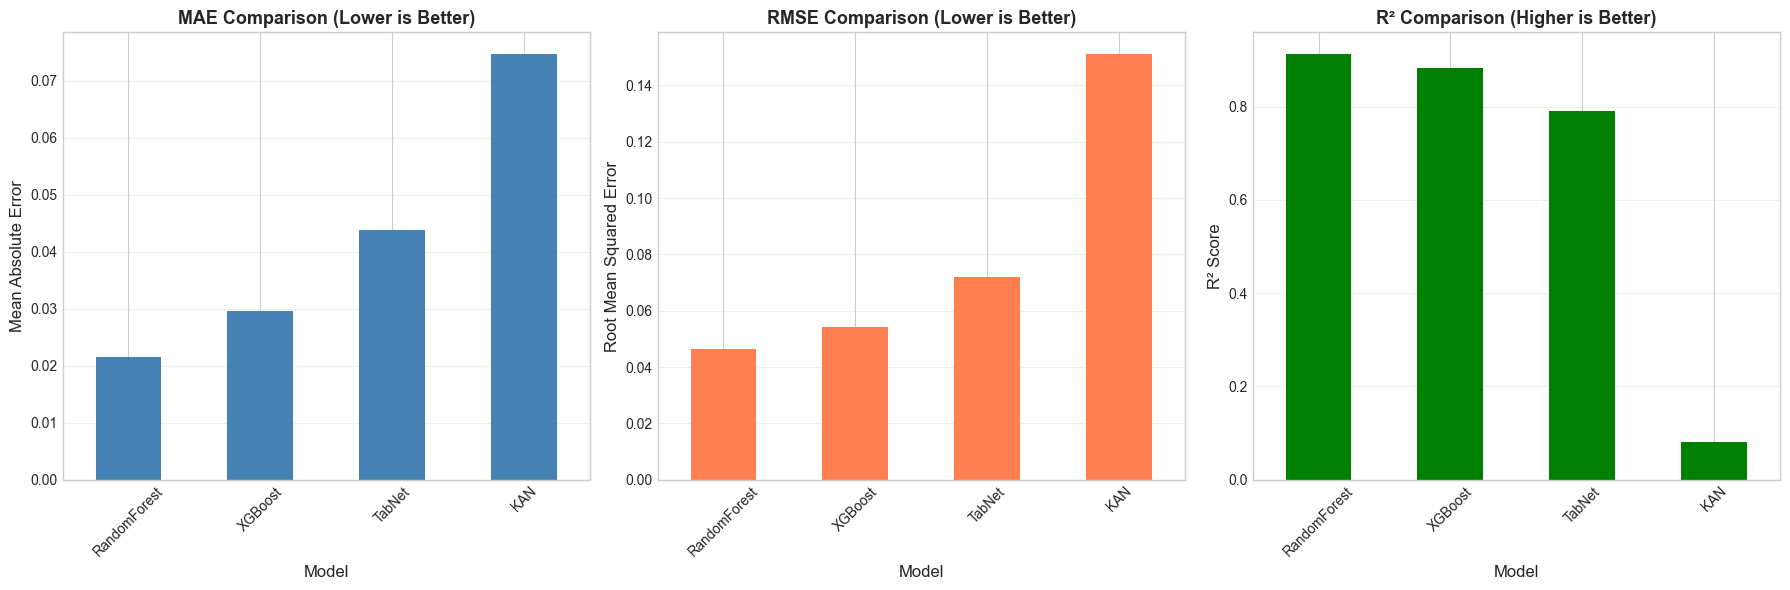

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

results_df.plot(x='Model', y='MAE', kind='bar', ax=axes[0], color='steelblue', legend=False)
axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('Mean Absolute Error', fontsize=12)
axes[0].set_title('MAE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

results_df.plot(x='Model', y='RMSE', kind='bar', ax=axes[1], color='coral', legend=False)
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('Root Mean Squared Error', fontsize=12)
axes[1].set_title('RMSE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

results_df.plot(x='Model', y='R²', kind='bar', ax=axes[2], color='green', legend=False)
axes[2].set_xlabel('Model', fontsize=12)
axes[2].set_ylabel('R² Score', fontsize=12)
axes[2].set_title('R² Comparison (Higher is Better)', fontsize=13, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
figures_dir = Path.cwd().parent / 'figures'
plt.savefig(figures_dir / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. SHAP Explainability Analysis

In [22]:
import shap

print("Computing SHAP values for XGBoost model...")
explainer = shap.TreeExplainer(pipeline.models['XGBoost'])
shap_values = explainer.shap_values(X_test)

print(f"SHAP values computed for {X_test.shape[0]} test samples")

Computing SHAP values for XGBoost model...
SHAP values computed for 4957 test samples
SHAP values computed for 4957 test samples


C:\Users\Kanchan\AppData\Local\Temp\ipykernel_11732\3490528728.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False, max_display=15)


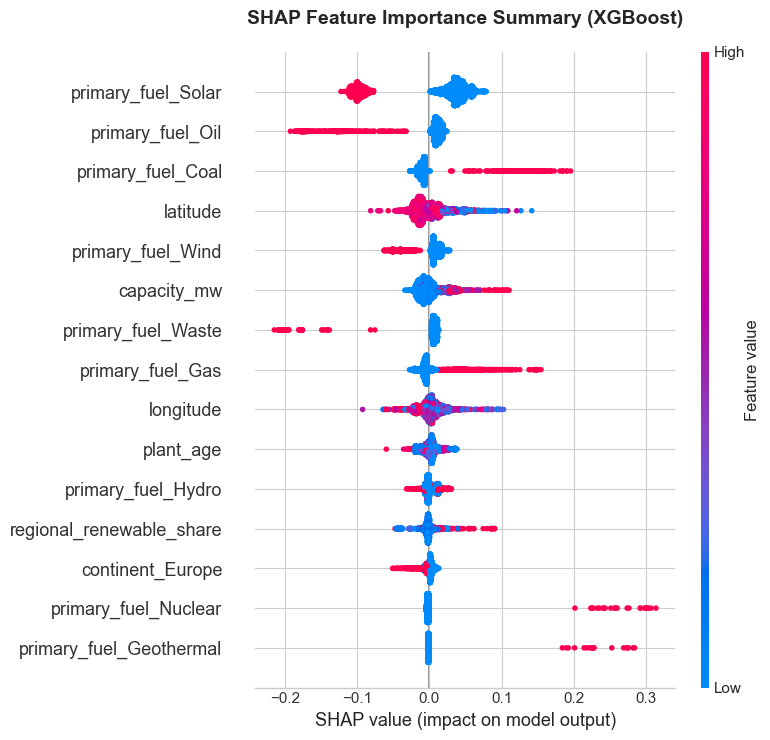

In [23]:
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title('SHAP Feature Importance Summary (XGBoost)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(figures_dir / 'shap_summary_notebook.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean |SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False)

print("\nTop 20 Most Important Features (by Mean Absolute SHAP):")
print(shap_importance.head(20).to_string(index=False))


Top 20 Most Important Features (by Mean Absolute SHAP):
                 Feature  Mean |SHAP|
      primary_fuel_Solar     0.057935
        primary_fuel_Oil     0.019764
       primary_fuel_Coal     0.018511
                latitude     0.016829
       primary_fuel_Wind     0.014935
             capacity_mw     0.012479
      primary_fuel_Waste     0.012297
        primary_fuel_Gas     0.011875
               longitude     0.010795
               plant_age     0.007934
      primary_fuel_Hydro     0.006003
regional_renewable_share     0.005381
        continent_Europe     0.004132
    primary_fuel_Nuclear     0.003608
 primary_fuel_Geothermal     0.002421
 continent_North America     0.001298
         log_capacity_mw     0.000789
          continent_Asia     0.000586
      primary_fuel_Other     0.000484
 continent_South America     0.000423


## 6. Prediction vs Actual Analysis

In [25]:
best_model_name = results_df.iloc[0]['Model']
best_model = pipeline.models[best_model_name]

print(f"Using best model: {best_model_name}")

if best_model_name == 'TabNet':
    y_pred = best_model.predict(X_test.values).flatten()
elif best_model_name == 'KAN':
    X_test_scaled = pipeline.scaler.transform(X_test)
    y_pred = best_model.forward(torch.tensor(X_test_scaled, dtype=torch.float32)).detach().numpy().flatten()
else:
    y_pred = best_model.predict(X_test)

Using best model: RandomForest


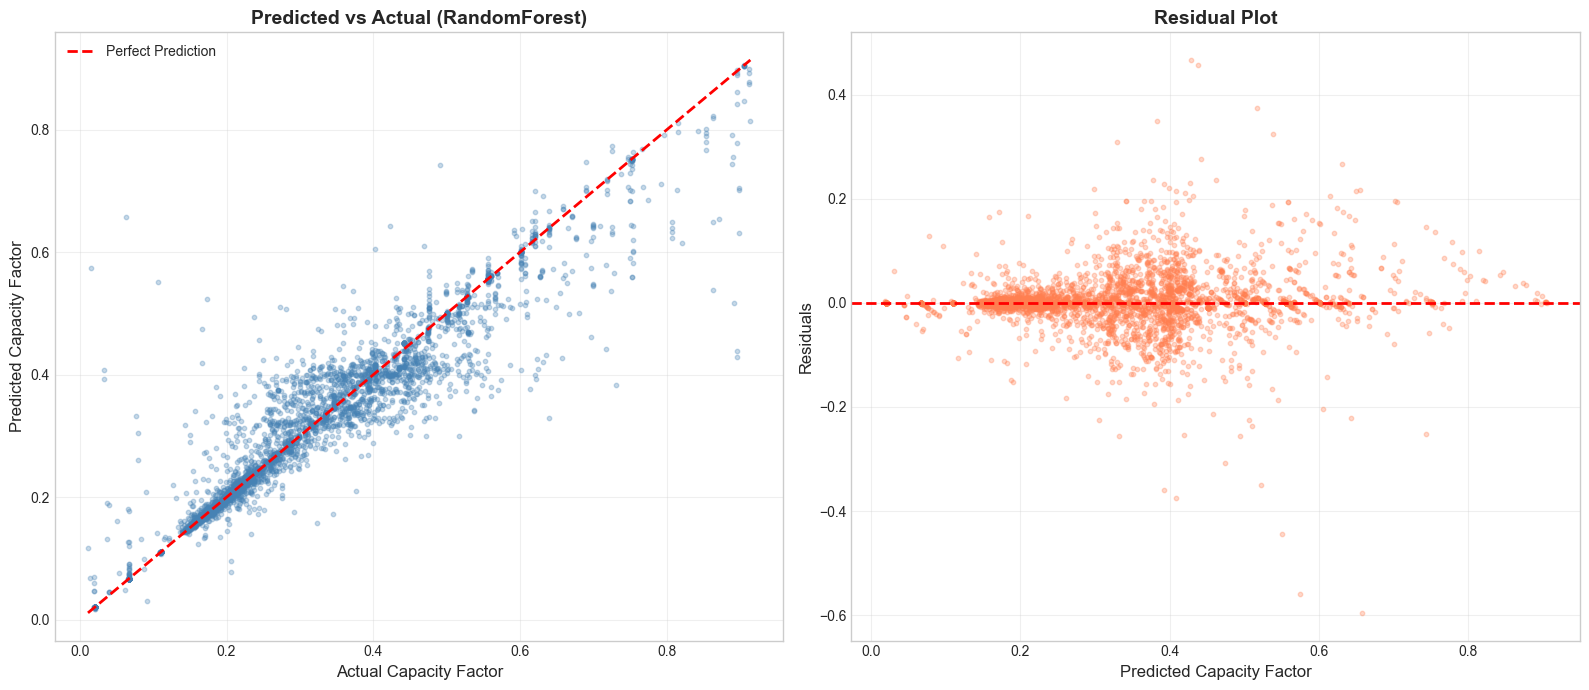

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
            'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Capacity Factor', fontsize=12)
axes[0].set_ylabel('Predicted Capacity Factor', fontsize=12)
axes[0].set_title(f'Predicted vs Actual ({best_model_name})', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, s=10, color='coral')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Capacity Factor', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'prediction_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Residual Distribution Analysis

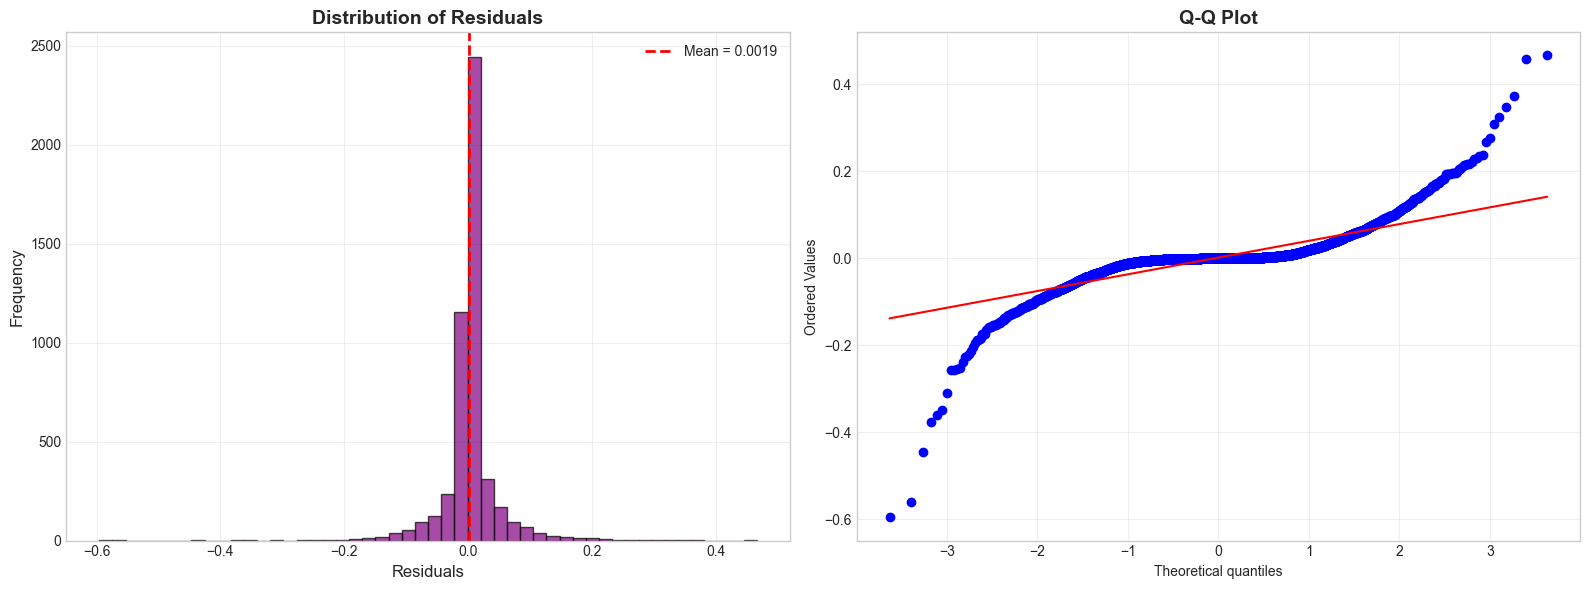

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(residuals, bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[0].axvline(residuals.mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Mean = {residuals.mean():.4f}')
axes[0].set_xlabel('Residuals', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Residuals', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
print(f"\nResidual Statistics:")
print(f"Mean: {residuals.mean():.4f}")
print(f"Std Dev: {residuals.std():.4f}")
print(f"Min: {residuals.min():.4f}")
print(f"Max: {residuals.max():.4f}")
print(f"Median: {residuals.median():.4f}")


Residual Statistics:
Mean: 0.0019
Std Dev: 0.0463
Min: -0.5956
Max: 0.4665
Median: -0.0000


## 8. Feature Importance (Random Forest)


Top 20 Features (Random Forest Importance):
                 Feature  Importance
      primary_fuel_Solar    0.226804
       primary_fuel_Coal    0.127613
               longitude    0.093246
        primary_fuel_Oil    0.092747
      primary_fuel_Waste    0.089112
       primary_fuel_Wind    0.084297
                latitude    0.083883
    primary_fuel_Nuclear    0.042663
      primary_fuel_Hydro    0.032817
               plant_age    0.025078
        primary_fuel_Gas    0.023982
             capacity_mw    0.022066
regional_renewable_share    0.016920
         log_capacity_mw    0.013895
        continent_Europe    0.011479
 continent_South America    0.004631
 primary_fuel_Geothermal    0.004475
      primary_fuel_Other    0.001681
        continent_Africa    0.000928
 continent_North America    0.000731


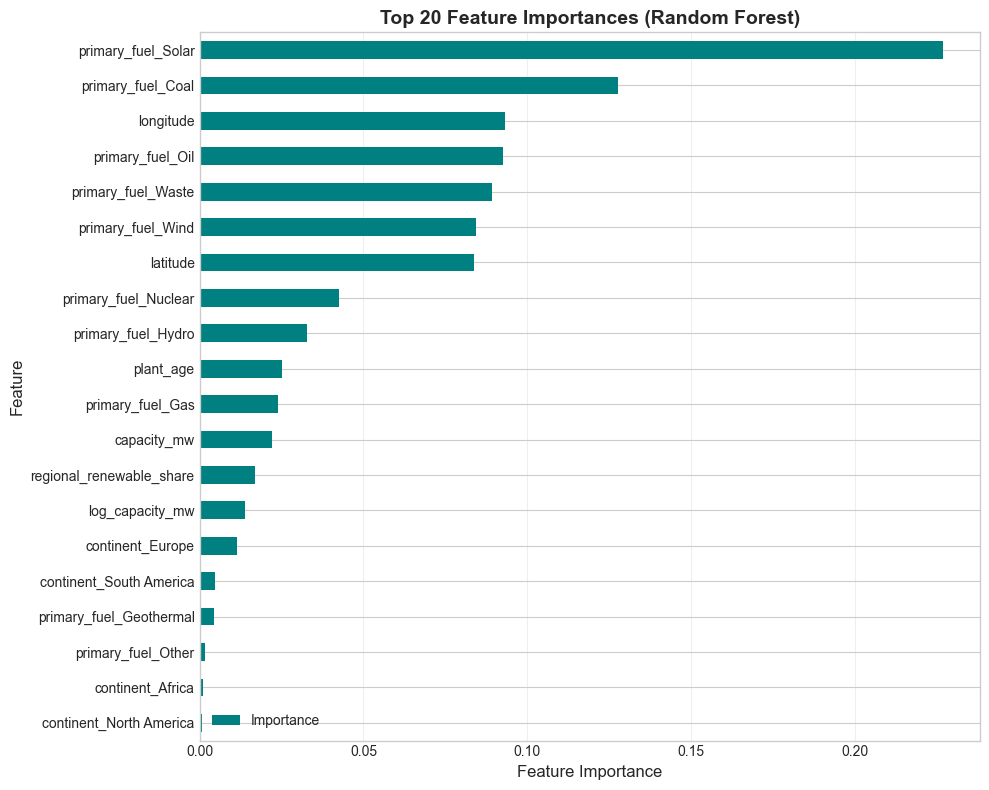

In [29]:
if 'RandomForest' in pipeline.models:
    rf_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': pipeline.models['RandomForest'].feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nTop 20 Features (Random Forest Importance):")
    print(rf_importance.head(20).to_string(index=False))
    
    fig, ax = plt.subplots(figsize=(10, 8))
    rf_importance.head(20).plot(x='Feature', y='Importance', kind='barh', ax=ax, color='teal')
    ax.set_xlabel('Feature Importance', fontsize=12)
    ax.set_ylabel('Feature', fontsize=12)
    ax.set_title('Top 20 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig(figures_dir / 'rf_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9. Error Analysis by Fuel Type

In [30]:
test_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred,
    'residual': residuals.values,
    'abs_error': np.abs(residuals.values)
})

test_df = test_df.join(df.loc[y_test.index, ['primary_fuel', 'is_renewable', 'continent']])

error_by_fuel = test_df.groupby('primary_fuel')['abs_error'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
error_by_fuel = error_by_fuel[error_by_fuel['count'] >= 20]

print("\nMean Absolute Error by Fuel Type:")
print(error_by_fuel.head(15))


Mean Absolute Error by Fuel Type:
                  mean    median  count
primary_fuel                           
Hydro         0.023652  0.005393    255
Gas           0.020831  0.005288     82
Wind          0.020794  0.003505    137
Oil           0.020636  0.004488    131
Coal          0.015633  0.002093     39
Solar         0.015341  0.003565     85


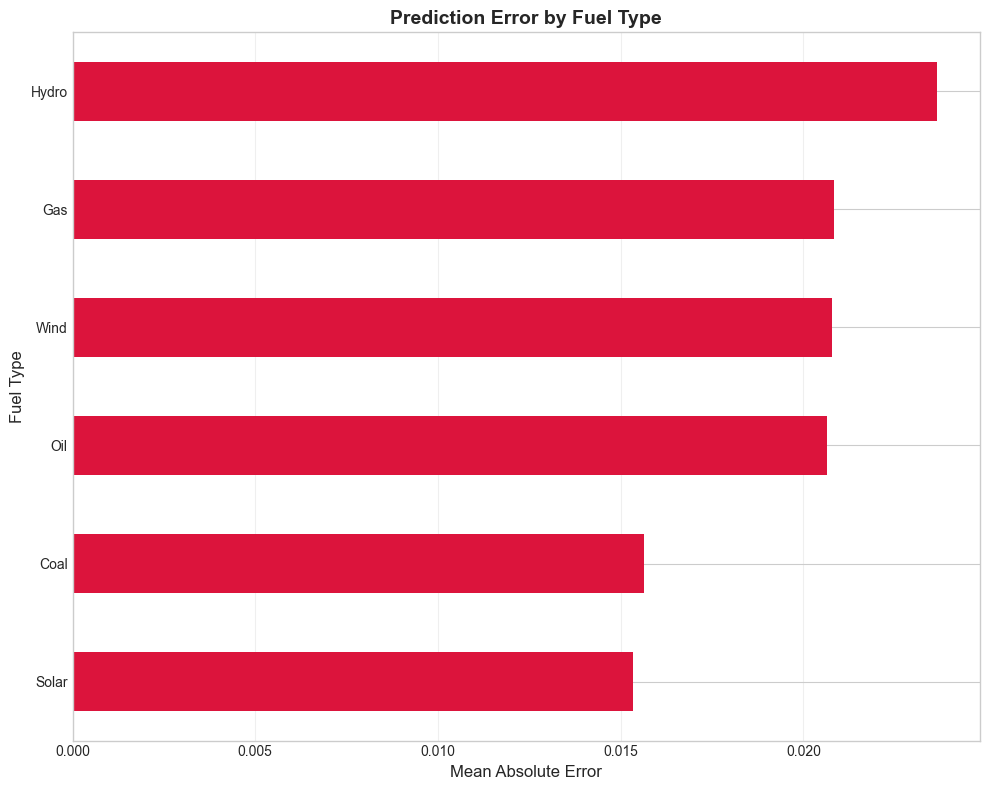

In [31]:
fig, ax = plt.subplots(figsize=(10, 8))

error_by_fuel.head(15)['mean'].plot(kind='barh', ax=ax, color='crimson')
ax.set_xlabel('Mean Absolute Error', fontsize=12)
ax.set_ylabel('Fuel Type', fontsize=12)
ax.set_title('Prediction Error by Fuel Type', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(figures_dir / 'error_by_fuel.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Model Performance Summary

In [32]:
print("\n" + "="*70)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("="*70)
print(f"\nBest Model: {best_model_name}")
print(f"Test R²: {results_df.iloc[0]['R²']:.4f}")
print(f"Test MAE: {results_df.iloc[0]['MAE']:.4f}")
print(f"Test RMSE: {results_df.iloc[0]['RMSE']:.4f}")
print(f"\nTest samples: {len(y_test):,}")
print(f"Features used: {X_test.shape[1]}")
print("\nAll Models Performance:")
print(results_df.to_string(index=False))
print("="*70)


FINAL MODEL PERFORMANCE SUMMARY

Best Model: RandomForest
Test R²: 0.9139
Test MAE: 0.0215
Test RMSE: 0.0463

Test samples: 4,957
Features used: 23

All Models Performance:
       Model      MAE     RMSE       R²
RandomForest 0.021467 0.046301 0.913882
     XGBoost 0.029676 0.054082 0.882503
      TabNet 0.043767 0.072118 0.791067
         KAN 0.074763 0.151268 0.080794


## Summary

Key findings from ML modeling:

1. **Model Comparison**: Multiple algorithms tested with consistent evaluation metrics
2. **Best Performance**: Top model identified based on R² score
3. **Feature Importance**: SHAP and RF importance reveal key predictive features
4. **Prediction Quality**: Scatter plots show alignment with actual values
5. **Residual Analysis**: Residuals approximately normally distributed
6. **Fuel Type Variation**: Prediction accuracy varies by generation technology
7. **Interpretability**: SHAP provides transparent feature contribution analysis

Models successfully predict capacity factors and identify key drivers of plant efficiency.